### Análise de Sentimentos em Reviews de Apps Brasileiros ###

Projeto de NLP aplicado a avaliações reais coletadas da Google Play Store,
com foco em texto em português brasileiro.

**Objetivo:** classificar o sentimento de reviews (positivo/neutro/negativo)
a partir do texto e da nota dada pelo usuário.

In [1]:
from google_play_scraper import reviews, Sort
import pandas as pd 
from pathlib import Path


### 1. Coleta de dados ###

Reviews coletados via `google-play-scraper`, app: Nubank (com.nu.production)

In [2]:
resultado, _ = reviews(
    'com.nu.production',  # app ID do Nubank na Play Store
    lang='pt',
    country='br',
    sort=Sort.NEWEST,
    count=500
)

df = pd.DataFrame(resultado)
print(df.shape)
df.head()


(500, 11)


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,d8e02dd3-b983-47c3-a719-626ab07b809b,Luciano Fonseca,https://play-lh.googleusercontent.com/a/ACg8oc...,"muito bom, facilita nossa correria do dia a di...",5,0,9.49.13-minApi28,2026-06-20 02:33:09,NaN,NaT,9.49.13-minApi28
1,729157aa-6056-4252-897e-8e8d4a2e0a82,Fernando Alves,https://play-lh.googleusercontent.com/a-/ALV-U...,não aumenta meu limite movimento otimo,3,0,9.49.51-minApi28,2026-06-20 02:09:58,NaN,NaT,9.49.51-minApi28
2,b66b0e43-a91c-404d-a50d-104ac4c93554,Graça Ferreira,https://play-lh.googleusercontent.com/a/ACg8oc...,muito boa.,5,0,9.49.51-minApi28,2026-06-20 02:07:18,NaN,NaT,9.49.51-minApi28
3,8ec5da84-8976-483d-a6d5-ba9d96137792,Leandro Solon,https://play-lh.googleusercontent.com/a-/ALV-U...,Quero ver abrir meu aplicativo,5,0,9.46.78-minApi28,2026-06-20 01:35:38,NaN,NaT,9.46.78-minApi28
4,5b36fa16-6956-4b3e-a847-3ac815f07c71,Wagner Monteiro,https://play-lh.googleusercontent.com/a/ACg8oc...,Boa demqis,5,0,NaN,2026-06-20 01:33:03,NaN,NaT,NaN


In [3]:
path = Path("../data/raw")
path.mkdir(parents=True, exist_ok=True)

df.to_csv(path / "reviews_nubank.csv", index=False)
print("Salvo com sucesso!")

Salvo com sucesso!


### 2. Exploração inicial ###

Verificando estrutura, tipos de dados e valores faltantes antes de seguir.

In [4]:
print("Colunas:", df.columns.tolist())
print("\nTipos de dados:")
print(df.dtypes)
print("\nValores nulos por coluna:")
print(df.isnull().sum())

Colunas: ['reviewId', 'userName', 'userImage', 'content', 'score', 'thumbsUpCount', 'reviewCreatedVersion', 'at', 'replyContent', 'repliedAt', 'appVersion']

Tipos de dados:
reviewId                           str
userName                           str
userImage                          str
content                            str
score                            int64
thumbsUpCount                    int64
reviewCreatedVersion               str
at                      datetime64[us]
replyContent                       str
repliedAt               datetime64[us]
appVersion                         str
dtype: object

Valores nulos por coluna:
reviewId                  0
userName                  0
userImage                 0
content                   0
score                     0
thumbsUpCount             0
reviewCreatedVersion     55
at                        0
replyContent            446
repliedAt               446
appVersion               55
dtype: int64


In [5]:
df_limpo = df[['userName', 'score', 'content', 'at']].copy()
df_limpo.columns = ['usuario', 'nota', 'texto', 'data']
df_limpo.head(10)

,usuario,nota,texto,data
0,Luciano Fonseca,5,"muito bom, facilita nossa correria do dia a di...",2026-06-20 02:33:09
1,Fernando Alves,3,não aumenta meu limite movimento otimo,2026-06-20 02:09:58
2,Graça Ferreira,5,muito boa.,2026-06-20 02:07:18
3,Leandro Solon,5,Quero ver abrir meu aplicativo,2026-06-20 01:35:38
4,Wagner Monteiro,5,Boa demqis,2026-06-20 01:33:03
5,Lucia Andrade,5,maravilhosa de mais ❤️,2026-06-20 01:32:54
6,Ageu Ferreira,5,Excelente 👌,2026-06-20 00:00:04
7,Duda Moreira,1,Não aparece mais o dinheiro que eu envio ao po...,2026-06-19 23:21:55
8,Ana Elizabete Santos Borges,5,muito bom,2026-06-19 23:14:36
9,Márcio Daniel,5,o banco do futuro!,2026-06-19 22:40:54


In [6]:
print(df_limpo['nota'].value_counts().sort_index())
print("\nMédia das notas:", df_limpo['nota'].mean().round(2))

nota
1     64
2     16
3     32
4     25
5    363
Name: count, dtype: int64

Média das notas: 4.21


### 3. Limpeza de texto ###

Removendo emojis, pontuação, números e padronizando para minúsculo.
A nota (estrelas) será usada como rótulo de sentimento — mais confiável
que tentar inferir sentimento a partir de emojis isoladamente

In [7]:
import re

def limpar_texto(texto):
    texto = texto.lower() #### Tudo minúsculo
    texto = re.sub(r'[^\w\s]', '', texto) #### Remove pontuação
    texto = re.sub(r'\d+', '', texto) #### Remove números
    texto = re.sub(r'\s+', ' ', texto).strip() #### Remove espaços extras
    return texto

df_limpo['texto_limpo'] = df_limpo['texto'].apply(limpar_texto)
df_limpo[['texto', 'texto_limpo']].head(5)

,texto,texto_limpo
0,"muito bom, facilita nossa correria do dia a di...",muito bom facilita nossa correria do dia a dia...
1,não aumenta meu limite movimento otimo,não aumenta meu limite movimento otimo
2,muito boa.,muito boa
3,Quero ver abrir meu aplicativo,quero ver abrir meu aplicativo
4,Boa demqis,boa demqis


### 4. Rotulagem de sentimento ###

Classificação baseada na nota:
-> 1-2 estrelas → negativo
-> 3 estrelas → neutro
-> 4-5 estrelas → positivo

In [8]:
def classificar_sentimento(nota):
    if nota <= 2:
        return 'negativo'
    elif nota == 3:
        return 'neutro'
    else:
        return 'positivo'

df_limpo['sentimento'] = df_limpo['nota'].apply(classificar_sentimento)
df_limpo['sentimento'].value_counts()

sentimento
positivo    388
negativo     80
neutro       32
Name: count, dtype: int64

In [9]:
path_processed = Path("../data/processed")
path_processed.mkdir(parents=True, exist_ok=True)
df_limpo.to_csv(path_processed / "reviews_nubank_limpo.csv", index=False)
print("Dataset processado salvo!")

Dataset processado salvo!


In [10]:
for texto in df_limpo['texto'].head(5):
    print(texto)
    print("-" * 50)

muito bom, facilita nossa correria do dia a dia, e bem fácil de usar eu amei 🤩🤩
--------------------------------------------------
não aumenta meu limite movimento otimo
--------------------------------------------------
muito boa.
--------------------------------------------------
Quero ver abrir meu aplicativo
--------------------------------------------------
Boa demqis
--------------------------------------------------


### 5. Visualização dos dados ###

Gráficos para entender a distribuição de notas e sentimentos.

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_style("whitegrid")

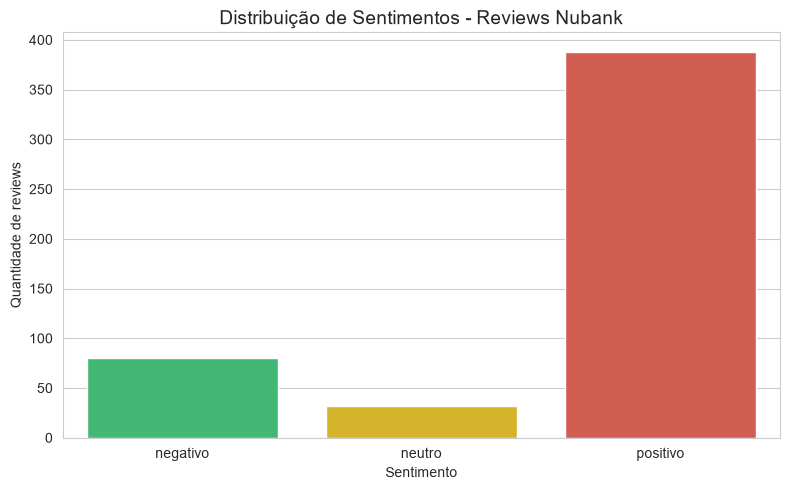

In [12]:
plt.figure(figsize=(8, 5))
ordem = ['negativo', 'neutro', 'positivo']
cores = ['#E74C3C', '#F1C40F', '#2ECC71']

sns.countplot(data=df_limpo, x='sentimento', order=ordem, hue='sentimento', palette=cores, legend=False)
plt.title('Distribuição de Sentimentos - Reviews Nubank', fontsize=14)
plt.xlabel('Sentimento')
plt.ylabel('Quantidade de reviews')
plt.tight_layout()
plt.savefig('../data/processed/grafico_sentimentos.png', dpi=150)
plt.show()

In [13]:
from collections import Counter

def palavras_mais_comuns(df, sentimento, n=10):
    textos = df[df['sentimento'] == sentimento]['texto_limpo']
    palavras = ' '.join(textos).split()
    contagem = Counter(palavras)
    return contagem.most_common(n)

print("Top palavras - NEGATIVO:")
print(palavras_mais_comuns(df_limpo, 'negativo'))
print("\nTop palavras - POSITIVO:")
print(palavras_mais_comuns(df_limpo, 'positivo'))



Top palavras - NEGATIVO:
[('o', 64), ('não', 63), ('de', 54), ('e', 52), ('que', 43), ('a', 41), ('mais', 25), ('com', 25), ('eu', 21), ('pra', 19)]

Top palavras - POSITIVO:
[('muito', 136), ('bom', 105), ('de', 87), ('o', 79), ('e', 74), ('que', 60), ('ótimo', 55), ('banco', 48), ('a', 41), ('melhor', 36)]
